# Season DJF (D year Y and JF year Y+1)

By Vincent Peyaud 13/05/2026

Plot seasonal mean by 2 methods for winter :
- Old way : DJF from same year (J 1961, F 1961, D 1961)
- New way : consecutive months (D 1960, J 1961, F 1961)

Example for one of mine datasets, just adapt the sctipt 

In [8]:
import xarray as xr
import numpy as np

In [2]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [13]:
filin=path_DIR+'GCM/MPI-ESM1-2-HR/historical/tas_Amon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_196001-201412.nc'
filin

'/Users/peyaudv/Glaciers/MAR_GCMs/GCM/MPI-ESM1-2-HR/historical/tas_Amon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_196001-201412.nc'

In [14]:
# Open your dataset
ds = xr.open_dataset(filin)
ds

<xarray.Dataset> Size: 195MB
Dimensions:    (time: 660, bnds: 2, lat: 192, lon: 384)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1960-01-16T12:00:00 ... 2014-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 11kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    tas        (time, lat, lon) float32 195MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MPI-M is licensed un...
    cmor_version:           3.5.0
    tracking_id:            hdl:21.14100/111bda20-147d-4ed2-8d7b-e1c04eed0609
    NCO:                    netCDF Operators version 4.9.1 (Homepage = http:/...

### 1. Assign Seasons to Each Month
First, create a season label for each timestamp, ensuring that December (D) is assigned to the previous year's winter (DJF).


In [84]:
tas = ds['tas']  # Your temperature variable

# Define a function to assign seasons (DJF, MAM, JJA, SON)
def assign_season(time):
    month = time.dt.month.values
    year = time.dt.year.values
    season = np.empty(len(month), dtype='U10')  # Use a larger dtype for labels

    # DJF: Dec (prev year), Jan, Feb
    djf_mask = (month == 12) | (month == 1) | (month == 2)
    season[djf_mask] = 'DJF'

    # MAM: Mar, Apr, May
    mam_mask = (month == 3) | (month == 4) | (month == 5)
    season[mam_mask] = 'MAM'

    # JJA: Jun, Jul, Aug
    jja_mask = (month == 6) | (month == 7) | (month == 8)
    season[jja_mask] = 'JJA'

    # SON: Sep, Oct, Nov
    son_mask = (month == 9) | (month == 10) | (month == 11)
    season[son_mask] = 'SON'

    # Adjust year for DJF (Dec, Jan, Feb belong to the previous year)
    year_adj = year.copy()
    year_adj[djf_mask] = year[djf_mask] - 1

    # Create season labels like "2020_DJF"
    season_label = [f"{y}_{s}" for y, s in zip(year_adj, season)]
    return season_label

# Assign seasons to the time coordinate
tas = tas.assign_coords(season=('time', assign_season(tas.time)))

### 2. Group by Season and Calculate Mean

Now, group by the season coordinate and compute the mean:

In [85]:
# Group by season and calculate mean
seasonal_mean = tas.groupby('season').mean()

# Extract DJF (winter) means
winter_mean = seasonal_mean.sel(season=[s for s in seasonal_mean.season if 'DJF' in s])
seasonal_mean[:,50,50]

<xarray.DataArray 'tas' (season: 220)> Size: 880B
array([285.15036, 284.09174, 282.91287, 285.2767 , 282.1976 , 283.7991 ,
       282.8414 , 285.80862, 281.68298, 283.6084 , 281.88718, 284.04733,
       282.2772 , 283.48145, 282.65213, 283.88943, 281.0841 , 283.66696,
       282.07193, 284.6362 , 281.01678, 283.75122, 281.7589 , 284.41348,
       281.10815, 285.0187 , 281.92868, 283.8997 , 281.0997 , 284.61044,
       282.42712, 285.2485 , 281.51944, 284.02487, 282.53445, 286.06253,
       281.96545, 283.7666 , 282.03156, 285.26715, 281.2098 , 283.33423,
       282.2948 , 284.43533, 281.57956, 283.4603 , 281.5665 , 283.92334,
       281.3521 , 284.21353, 281.42606, 284.033  , 281.56744, 285.09152,
       282.79153, 285.50385, 281.57605, 284.81308, 282.7434 , 285.9985 ,
       281.59497, 284.58597, 283.91946, 285.01797, 281.7106 , 284.70718,
       282.31528, 284.82336, 281.9053 , 284.95752, 282.8741 , 285.5106 ,
       281.62405, 284.4884 , 283.08408, 284.03625, 281.6393 , 284.58926,
       282.74545, 284.32788, 281.76657, 284.68164, 283.00888, 284.98874,
       282.35303, 284.49048, 282.7052 , 284.95377, 282.29584, 285.16   ,
       282.69565, 285.698  , 282.2611 , 284.2602 , 282.87692, 285.0814 ,
       281.97934, 284.13208, 282.1283 , 284.74203, 281.70004, 284.52515,
       282.4026 , 284.39648, 281.79614, 284.28946, 282.42468, 285.52612,
       282.31662, 285.75888, 282.9833 , 283.99905, 282.67856, 284.74384,
       283.5898 , 285.7965 , 282.92532, 284.94556, 282.882  , 286.2121 ,
       282.27637, 285.18915, 282.59152, 285.85587, 283.41406, 284.5365 ,
       283.25543, 286.54407, 282.1819 , 284.65604, 283.54324, 284.85556,
       282.5071 , 284.66672, 283.5814 , 285.17184, 282.57108, 283.92825,
       282.74976, 285.11935, 281.93164, 284.73325, 282.29297, 284.9244 ,
       281.9194 , 285.26852, 281.79642, 284.49902, 281.78976, 284.777  ,
       282.6233 , 285.07016, 282.2205 , 284.98834, 282.50525, 285.7349 ,
       281.96866, 284.23605, 281.933  , 284.15613, 281.54037, 283.8467 ,
       282.54446, 284.88828, 281.40503, 285.13287, 282.21835, 283.87698,
       281.7948 , 285.4262 , 283.1263 , 284.88303, 282.19284, 285.76797,
       283.3297 , 286.21384, 281.71722, 284.81558, 282.67865, 286.34668,
       282.0548 , 285.2661 , 283.23026, 286.321  , 282.34305, 285.16217,
       283.68228, 285.57193, 282.1002 , 285.02856, 282.08594, 285.14612,
       281.7047 , 285.9379 , 283.57245, 285.85254, 283.4877 , 285.50662,
       283.44336, 285.97012, 282.29727, 284.77396, 282.21777, 285.13126,
       281.97833, 285.07962, 282.51538, 285.11774, 282.28918, 285.90247,
       283.01627, 285.12546, 282.45923, 285.16855, 283.10587, 286.7452 ,
       282.6385 , 283.78806, 285.72385, 282.0885 ], dtype=float32)
Coordinates:
    lat      float64 8B -42.55
    lon      float64 8B 46.88
    height   float64 8B ...
  * season   (season) object 2kB '1959_DJF' '1960_DJF' ... '2014_MAM' '2014_SON'
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-08-25T09:53:57Z altered by CMOR: Treated scalar dime...

In [86]:
# test
t= np.arange(len(seasonal_mean[:,50,50]))
t[:5]

array([0, 1, 2, 3, 4])

### Best alternative : Using pandas for Season Assignment

If you prefer, you can also use pandas to handle the season assignment (since xarray integrates well with pandas):

In [116]:
import pandas as pd

# Convert time to pandas Index
time_pd = tas.time.to_index()

# Assign seasons using pandas
def get_season(t):
    if t.month in [12, 1, 2]:
        return f"{t.year - 1}_DJF" if t.month == 12 else f"{t.year}_DJF"
    elif t.month in [3, 4, 5]:
        return f"{t.year}_MAM"
    elif t.month in [6, 7, 8]:
        return f"{t.year}_JJA"
    elif t.month in [9, 10, 11]:
        return f"{t.year}_SON"

season_labels = [get_season(t) for t in time_pd]
tas = tas.assign_coords(season=('time', season_labels))

# Group by season and calculate mean
seasonal_mean = tas.groupby('season').mean()

In [117]:
#seasonal_mean

In [118]:
print(tas.shape)
print(seasonal_mean.shape)
print(dates.shape)

(660, 192, 384)
(221, 192, 384)
(220,)


### convert  season label in date (datetime) 

In [119]:
# Fonction pour convertir une saison en date
def season_to_date(season_lab):
    str_season=str(season_lab.values) # convert season_lab (label) into a string
    #print(str_season)
    year, season = str_season.split('_')
    year = int(year)

    # Associer chaque saison à un mois représentatif
    if season == 'DJF':
        # DJF = Décembre (année précédente), Janvier, Février → 1er janvier de l'année suivante
        return pd.Timestamp(f"{year + 1}-01-01")
    elif season == 'MAM':
        # MAM = Mars, Avril, Mai → 1er avril
        return pd.Timestamp(f"{year}-04-01")
    elif season == 'JJA':
        # JJA = Juin, Juillet, Août → 1er juillet
        return pd.Timestamp(f"{year}-07-01")
    elif season == 'SON':
        # SON = Septembre, Octobre, Novembre → 1er octobre
        return pd.Timestamp(f"{year}-10-01")
    else:
        raise ValueError(f"Saison inconnue : {season}")

# Appliquer la conversion à tout le tableau
dates = np.array([season_to_date(s) for s in seasonal_mean.season])

print(dates[:5])

[Timestamp('1960-01-01 00:00:00') Timestamp('1961-01-01 00:00:00')
 Timestamp('1960-07-01 00:00:00') Timestamp('1960-04-01 00:00:00')
 Timestamp('1960-10-01 00:00:00')]


#### Tu peux choisir une autre date pour représenter la saison, par exemple :

Milieu de la saison :

DJF → 15 janvier (f"{year + 1}-01-15")
MAM → 15 avril (f"{year}-04-15")
JJA → 15 juillet (f"{year}-07-15")
SON → 15 octobre (f"{year}-10-15")


In [120]:
# Fonction pour convertir une saison en date
def season_to_date2(season_lab):
    str_season=str(season_lab.values) # convert season_lab (label) into a string
    #print(str_season)
    year, season = str_season.split('_')
    year = int(year)

    # Associer chaque saison à un mois représentatif
    if season == 'DJF':
        # DJF = Décembre (année précédente), Janvier, Février → 1er janvier de l'année suivante
        return pd.Timestamp(f"{year + 1}-01-15")
    elif season == 'MAM':
        # MAM = Mars, Avril, Mai → 1er avril
        return pd.Timestamp(f"{year}-04-15")
    elif season == 'JJA':
        # JJA = Juin, Juillet, Août → 1er juillet
        return pd.Timestamp(f"{year}-07-15")
    elif season == 'SON':
        # SON = Septembre, Octobre, Novembre → 1er octobre
        return pd.Timestamp(f"{year}-10-15")
    else:
        raise ValueError(f"Saison inconnue : {season}")

# Appliquer la conversion à tout le tableau
dates2 = np.array([season_to_date2(s) for s in seasonal_mean.season])

print(dates2[:5])

[Timestamp('1960-01-15 00:00:00') Timestamp('1961-01-15 00:00:00')
 Timestamp('1960-07-15 00:00:00') Timestamp('1960-04-15 00:00:00')
 Timestamp('1960-10-15 00:00:00')]


### 3 Old way : season DJF from the same year

In [121]:
T_season= np.zeros((55, 4))
T_season[:,0] = ds.tas[:,50,50].sel(time=ds.tas.time.dt.season=="DJF").groupby("time.year").sum("time")
T_season[:,1] = ds.tas[:,50,50].sel(time=ds.tas.time.dt.season=="MAM").groupby("time.year").sum("time")
T_season[:,2] = ds.tas[:,50,50].sel(time=ds.tas.time.dt.season=="JJA").groupby("time.year").sum("time") 
T_season[:,3] = ds.tas[:,50,50].sel(time=ds.tas.time.dt.season=="SON").groupby("time.year").sum("time")

<b>Better:</b>

In [122]:
import pandas as pd

# Convert time to pandas Index
time_pd = tas.time.to_index()

# Assign seasons using pandas
def get_OldSeason(t):
    if t.month in [12, 1, 2]:
        return f"{t.year}_DJF"
    elif t.month in [3, 4, 5]:
        return f"{t.year}_MAM"
    elif t.month in [6, 7, 8]:
        return f"{t.year}_JJA"
    elif t.month in [9, 10, 11]:
        return f"{t.year}_SON"

Oldseason_labels = [get_OldSeason(t) for t in time_pd]
tas = tas.assign_coords(Oldseason=('time', Oldseason_labels))

# Group by season and calculate mean
seasonal_Oldmean = tas.groupby('Oldseason').mean()

### 4 Plot

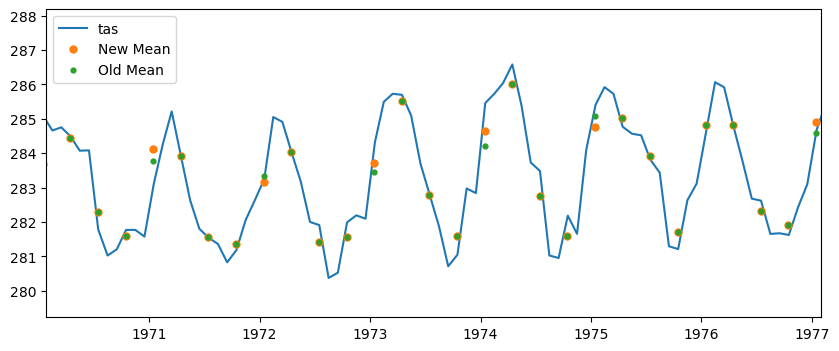

In [127]:
import datetime
plt.figure(figsize=(10,4))
plt.plot(tas.time,tas[:,50,50],label='tas')
#plt.plot(dates, seasonal_mean[:,50,50],'.',label='tas')
plt.plot(dates2,seasonal_mean[:,50,50],'.',ms='10',label='New Mean')
plt.plot(dates2[1:],seasonal_Oldmean[:,50,50],'.',ms='7',label='Old Mean')
#plt.step(dates2,seasonal_mean[:,50,50],where='mid',label='tas')
#plt.step(dates2,seasonal_Oldmean[:,50,50],where='mid',alpha=0.5,label='tas')
plt.xlim([datetime.date(1970, 1, 26), datetime.date(1977, 2, 1)])
plt.legend()